# EDA & Preprocessing

**Project:** Claude Investment Score (replication + extension of Jha et al. 2024)

This notebook loads all raw data, explores each dataset, and produces a clean merged file ready for scoring.

In [1]:
# libraries 
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# pandas options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# reproducibility 
np.random.seed(7524)

# paths
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'data'))
DATA = os.path.join('..', 'data')
TRANSCRIPTS_PATH =os.path.join(DATA, 'transcripts', 'transcripts.parquet')
COMPUSTAT_PATH = os.path.join(DATA, 'financials', 'compustat_quarterly.parquet')
CCM_PATH = os.path.join(DATA, 'financials', 'ccm_link.parquet')
CRSP_PATH = os.path.join(DATA, 'financials', 'crsp_monthly.parquet')

## 1. Transcripts

In [2]:
# read transcripts data
tr = pd.read_parquet(TRANSCRIPTS_PATH)

# rows and columns
print(f"Number of rows and columns: {tr.shape}")

# column names and first 5 rows
print(f"Columns: {list(tr.columns)}")
tr.head(5)

Number of rows and columns: (33362, 8)
Columns: ['symbol', 'quarter', 'year', 'date', 'content', 'structured_content', 'company_name', 'company_id']


,symbol,quarter,year,date,content,structured_content,company_name,company_id
0,A,4,2020,2020-11-23 16:30:00,"Operator: Good afternoon, and welcome to the A...","[{'speaker': 'Operator', 'text': 'Good afterno...","Agilent Technologies, Inc.",154924.0000
1,A,3,2020,2020-08-18 16:30:00,"Operator: Good afternoon, and welcome to the A...","[{'speaker': 'Operator', 'text': 'Good afterno...","Agilent Technologies, Inc.",154924.0000
2,A,2,2020,2020-05-21 16:30:00,"Operator: Good afternoon, and welcome to the A...","[{'speaker': 'Operator', 'text': 'Good afterno...","Agilent Technologies, Inc.",154924.0000
3,A,1,2020,2020-02-18 16:30:00,Operator: Good afternoon and welcome to the Ag...,"[{'speaker': 'Operator', 'text': 'Good afterno...","Agilent Technologies, Inc.",154924.0000
4,A,4,2021,2021-11-22 16:30:00,Operator: Good afternoon and welcome to the Ag...,"[{'speaker': 'Operator', 'text': 'Good afterno...","Agilent Technologies, Inc.",154924.0000


In [3]:
# checling for nulls and coverage
print("=== Nulls ===")
print(tr.isnull().sum())
print()

# Timeline coverage
print("=== Coverage ===")
print(f"Companies:       {tr['symbol'].nunique()}")
print(f"Date range:      {tr['date'].min()}  to  {tr['date'].max()}")
print(f"Transcripts:     {len(tr):,}")
print(f"Avg per company: {len(tr)/tr['symbol'].nunique():.1f}")

=== Nulls ===
symbol                   0
quarter                  0
year                     0
date                     0
content                  0
structured_content       0
company_name          8985
company_id            8985
dtype: int64

=== Coverage ===
Companies:       685
Date range:      2005-10-13 14:45:00  to  2025-05-15 16:30:00
Transcripts:     33,362
Avg per company: 48.7


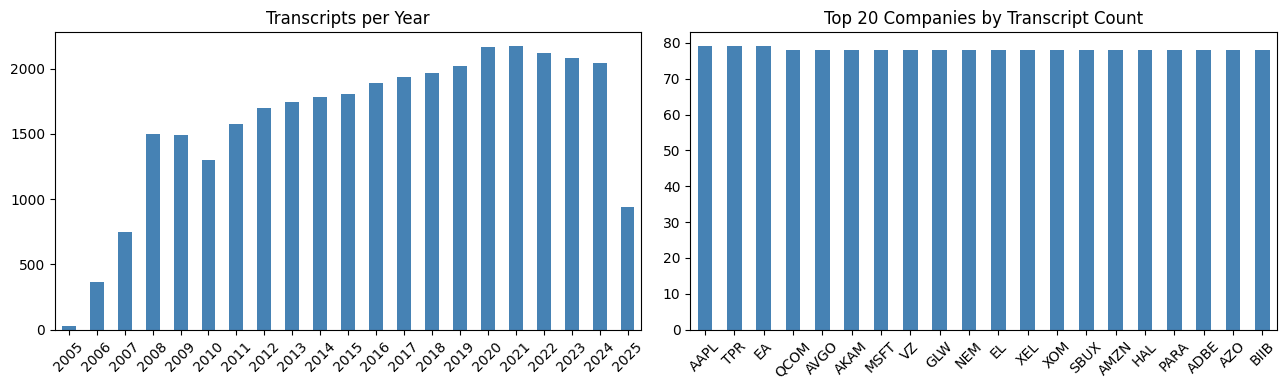

In [4]:
# Transcripts per year
tr['date'] = pd.to_datetime(tr['date'])
tr['year'] = tr['date'].dt.year

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

tr.groupby('year').size().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Transcripts per Year')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

tr.groupby('symbol').size().sort_values(ascending=False).head(20).plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Top 20 Companies by Transcript Count')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

=== Content length (chars) ===
count    33362.0000
mean     53423.6185
std      12773.7314
min          0.0000
25%      47251.2500
50%      53734.0000
75%      59519.7500
max     244695.0000


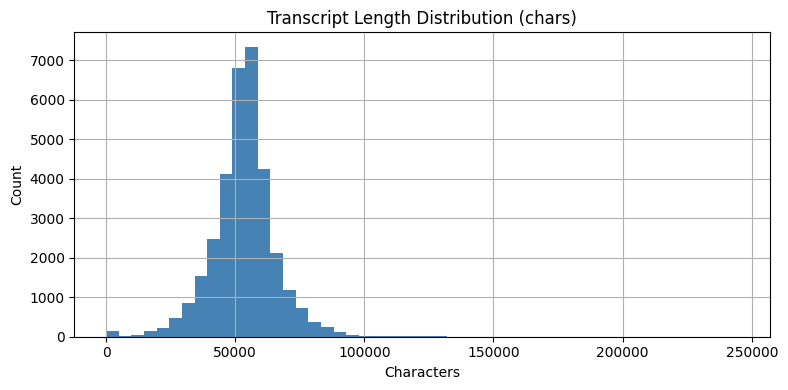

In [5]:
# Text length distribution
tr['content_len'] = tr['content'].str.len()
print("=== Content length (chars) ===")
print(tr['content_len'].describe().to_string())

tr['content_len'].hist(bins=50, color='steelblue', figsize=(8, 4))
plt.title('Transcript Length Distribution (chars)')
plt.xlabel('Characters')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [6]:
# Inspect structured_content — this is our speaker-level field
sample = tr.loc[tr['structured_content'].notna(), 'structured_content'].iloc[0]
print(f"Type: {type(sample)}")
print(f"Length (speakers): {len(sample)}")
print()
for turn in sample[:4]:
    print(f"Speaker: {turn['speaker']}")
    print(f"Text:    {turn['text'][:120]}...")
    print()

Type: <class 'numpy.ndarray'>
Length (speakers): 113

Speaker: Operator
Text:    Good afternoon, and welcome to the Agilent Technologies Fourth Quarter Earnings Conference Call. All lines have been pla...

Speaker: Ankur Dhingra
Text:    Thank you, and welcome everyone to Agilent's fourth quarter and full-year conference call for fiscal year 2020. With me ...

Speaker: Mike McMullen
Text:    Thanks, Ankur, and thanks to everyone for joining us on our call today. Today, I want to get straight to our quarterly r...

Speaker: Bob McMahon
Text:    Thanks, Mike, and good afternoon, everyone. In my remarks today, I'll provide some additional revenue detail, and take y...



In [7]:
# How many transcripts have structured_content vs plain content only
n_structured = tr['structured_content'].notna().sum()
print(f"Has structured_content: {n_structured:,} / {len(tr):,} ({100*n_structured/len(tr):.1f}%)")

Has structured_content: 33,362 / 33,362 (100.0%)


## 2. Compustat

In [8]:
cq = pd.read_parquet(COMPUSTAT_PATH)
print(f"Shape: {cq.shape}")
print(f"Columns: {list(cq.columns)}")
cq.head(3)

Shape: (50777, 19)
Columns: ['gvkey', 'tic', 'conm', 'datadate', 'fyearq', 'fqtr', 'capsq', 'atq', 'ppentq', 'xrdq', 'xsgaq', 'cshoq', 'prccq', 'dlttq', 'dlcq', 'oibdpq', 'saleq', 'epspxq', 'sic']


,gvkey,tic,conm,datadate,fyearq,fqtr,capsq,atq,ppentq,xrdq,xsgaq,cshoq,prccq,dlttq,dlcq,oibdpq,saleq,epspxq,sic
0,001045,AAL,AMERICAN AIRLINES GROUP INC,2005-03-31,2005,1,2509.0000,29167.0000,19116.0000,<NA>,617.0000,161.3900,10.7000,13375.0000,879.0000,313.0000,4750.0000,-1.0000,4512
1,001045,AAL,AMERICAN AIRLINES GROUP INC,2005-06-30,2005,2,2380.0000,29494.0000,19096.0000,<NA>,636.0000,163.7010,12.1100,13322.0000,910.0000,515.0000,5309.0000,0.3500,4512
2,001045,AAL,AMERICAN AIRLINES GROUP INC,2005-09-30,2005,3,2314.0000,29436.0000,18911.0000,<NA>,737.0000,165.0680,11.1800,13231.0000,960.0000,320.0000,5485.0000,-0.9300,4512


In [9]:
print("=== Nulls (%) ===")
print((cq.isnull().mean() * 100).round(1).to_string())
print()
print("=== Coverage ===")
print(f"Firms:          {cq['gvkey'].nunique()}")
print(f"Date range:     {cq['datadate'].min().date()}  to  {cq['datadate'].max().date()}")
print(f"Firm-quarters:  {len(cq):,}")

=== Nulls (%) ===
gvkey       0.0000
tic         0.0000
conm        0.0000
datadate    0.0000
fyearq      0.0000
fqtr        0.0000
capsq       2.3000
atq         0.0000
ppentq      6.3000
xrdq       53.1000
xsgaq      19.3000
cshoq       0.5000
prccq       1.1000
dlttq       0.5000
dlcq        7.5000
oibdpq      8.8000
saleq       0.0000
epspxq      0.3000
sic         0.0000

=== Coverage ===
Firms:          662
Date range:     2005-01-31  to  2025-12-31
Firm-quarters:  50,777


In [10]:
print("=== Key variables summary ===")
cq[['atq', 'capsq', 'ppentq', 'xrdq', 'xsgaq', 'oibdpq', 'saleq']].describe().round(3)

=== Key variables summary ===


,atq,capsq,ppentq,xrdq,xsgaq,oibdpq,saleq
count,50777.0000,49616.0000,47599.0000,23833.0000,40957.0000,46320.0000,50760.0000
mean,62757.9180,6525.3110,7884.2850,285.9780,934.7700,1055.9570,4869.5600
std,258204.0590,13607.4280,19434.1170,1054.9930,2407.4700,2649.1440,10796.1620
min,1.0610,-1976.9000,0.0000,-11.0000,-923.0000,-35254.0000,-25623.0000
25%,4800.0000,535.6740,459.0000,0.0000,126.4000,144.1270,693.7750
50%,12799.3000,2035.5150,1658.6960,35.6330,311.0000,362.0000,1710.0000
75%,34639.0000,6263.0000,6770.9000,179.0000,753.3310,922.0000,4104.0000
max,4560205.0000,158048.7760,443079.0000,29399.0000,76293.0000,54066.0000,213386.0000


## 3. CCM Link

In [11]:
ccm = pd.read_parquet(CCM_PATH)
print(f"Shape: {ccm.shape}")
ccm.head(5)

Shape: (862, 6)


,gvkey,permno,linktype,linkprim,linkdt,linkenddt
0,001045,21020.0000,LC,C,1950-01-01,1962-01-30
1,001045,21020.0000,LC,P,1962-01-31,2012-01-04
2,001045,21020.0000,LC,P,2013-12-09,NaT
3,001075,27991.0000,LU,P,1962-01-31,NaT
4,001078,20482.0000,LC,C,1950-01-01,1962-01-30


In [12]:
# Some gvkeys have multiple permnos (e.g. after spin-offs, ticker changes)
dups = ccm.groupby('gvkey')['permno'].nunique()
print(f"gvkeys with >1 permno: {(dups > 1).sum()}")
print(f"Nulls in permno: {ccm['permno'].isna().sum()}")

gvkeys with >1 permno: 73
Nulls in permno: 0


## 4. CRSP

In [13]:
crsp = pd.read_parquet(CRSP_PATH)
print(f"Shape: {crsp.shape}")
crsp.head(3)

Shape: (143917, 5)


,permno,date,ret,prc,shrout
0,10104,2005-01-31,0.0036,13.7700,5224866.0000
1,10104,2005-02-28,-0.0595,12.9500,5136000.0000
2,10104,2005-03-31,-0.0363,12.4800,5141381.0000


In [14]:
print("=== Nulls (%) ===")
print((crsp.isnull().mean() * 100).round(1).to_string())
print()
print("=== Coverage ===")
print(f"Firms:         {crsp['permno'].nunique()}")
print(f"Date range:    {crsp['date'].min().date()}  to  {crsp['date'].max().date()}")
print(f"Firm-months:   {len(crsp):,}")
print()
print("=== Returns summary ===")
print(crsp['ret'].describe().round(4).to_string())

=== Nulls (%) ===
permno   0.0000
date     0.0000
ret      0.4000
prc      0.3000
shrout   0.1000

=== Coverage ===
Firms:         702
Date range:    2005-01-31  to  2024-12-31
Firm-months:   143,917

=== Returns summary ===
count   143385.0000
mean         0.0127
std          0.1163
min         -0.9027
25%         -0.0393
50%          0.0119
75%          0.0615
max         16.2505


## 5. Merge

Pipeline:

1. `transcripts` + `compustat` - match on ticker + fiscal year + fiscal quarter

2. Join `ccm_link` on gvkey → get permno (with valid date range)

3. Join `crsp` on permno

In [15]:
# Step 1: transcripts x compustat
tr['year']    = tr['date'].dt.year
tr['quarter'] = tr['date'].dt.quarter

merged = tr.merge(
    cq,
    left_on  = ['symbol', 'year', 'quarter'],
    right_on = ['tic', 'fyearq', 'fqtr'],
    how='inner'
)
print(f"After transcript x Compustat: {len(merged):,} rows, {merged['symbol'].nunique()} firms")

After transcript x Compustat: 32,253 rows, 650 firms


In [16]:
# Step 2: attach permno via CCM link
# Keep only valid links: linkdt <= datadate <= linkenddt (NaT linkenddt = still active)
ccm_clean = ccm.dropna(subset=['permno']).copy()
ccm_clean['permno'] = ccm_clean['permno'].astype(int)
ccm_clean['linkenddt'] = ccm_clean['linkenddt'].fillna(pd.Timestamp('2099-12-31'))

merged = merged.merge(ccm_clean[['gvkey', 'permno', 'linkdt', 'linkenddt']], on='gvkey', how='left')
merged = merged[
    (merged['permno'].notna()) &
    (merged['datadate'] >= merged['linkdt']) &
    (merged['datadate'] <= merged['linkenddt'])
].drop(columns=['linkdt', 'linkenddt'])

print(f"After CCM link: {len(merged):,} rows, {merged['symbol'].nunique()} firms")

After CCM link: 32,066 rows, 646 firms


In [17]:
# Step 3: attach CRSP returns
# Match the month after the quarter end (t+1 return)
crsp['year_month'] = crsp['date'].dt.to_period('M')
merged['return_month'] = (merged['datadate'] + pd.offsets.MonthEnd(1)).dt.to_period('M')

merged = merged.merge(
    crsp[['permno', 'year_month', 'ret', 'prc', 'shrout']],
    left_on  = ['permno', 'return_month'],
    right_on = ['permno', 'year_month'],
    how='left'
).drop(columns=['year_month_x', 'year_month_y'], errors='ignore')

print(f"After CRSP: {len(merged):,} rows, {merged['symbol'].nunique()} firms")
print(f"Return coverage: {merged['ret'].notna().mean()*100:.1f}%")

After CRSP: 32,066 rows, 646 firms
Return coverage: 95.8%


## 6. Preprocessing

Drop columns we don't need, clean types, handle duplicates.

In [18]:
# Drop redundant merge keys
drop_cols = ['tic', 'fyearq', 'fqtr', 'return_month', 'company_id',
             '__fragment_index', '__batch_index', '__last_in_fragment', '__filename']
merged = merged.drop(columns=[c for c in drop_cols if c in merged.columns])

# Deduplicate: keep one row per symbol x datadate (in case CCM had multiple links)
before = len(merged)
merged = merged.drop_duplicates(subset=['symbol', 'datadate'])
print(f"Dropped {before - len(merged)} duplicate rows")
print(f"Final shape: {merged.shape}")

Dropped 195 duplicate rows
Final shape: (31871, 29)


In [19]:
# Final null check on key columns
key_cols = ['symbol', 'datadate', 'gvkey', 'permno', 'atq', 'capsq', 'ppentq', 'ret', 'content', 'structured_content']
print("=== Nulls in key columns (%) ===")
print((merged[key_cols].isnull().mean() * 100).round(1).to_string())

=== Nulls in key columns (%) ===
symbol               0.0000
datadate             0.0000
gvkey                0.0000
permno               0.0000
atq                  0.0000
capsq                1.1000
ppentq               6.1000
ret                  4.2000
content              0.0000
structured_content   0.0000


In [27]:
# Save merged dataset — ready for scorer
out = os.path.join('..', 'data', 'merged.parquet')
merged.to_parquet(out, index=False)
print(f"Saved to {out}")
print(f"  {len(merged):,} firm-quarters, {merged['symbol'].nunique()} firms")

Saved to ..\data\merged.parquet
  31,871 firm-quarters, 646 firms
